# Lab 02 — Time-Series Anomaly Detection

Lab 01 scored each sample against the whole month. That works when an anomaly is extreme in
absolute terms, and fails when it is only extreme *for its time of day*. A 3 a.m. backup that
moves as much traffic as a Tuesday lunchtime is the second kind, and no global statistic will
ever see it.

This lab is about respecting the time axis. Same three choices as before, but the model of
normal now depends on when a sample arrived.

## Learning outcomes

1. Detect and measure the daily cycle in an interface counter.
2. Split and scale a time series without leaking the future into the past.
3. Build a matrix-profile baseline in numpy and read its discord.
4. Fit `IsolationForest`, `OneClassSVM` and `LocalOutlierFactor` on raw values and watch
   them miss a contextual anomaly completely.
5. Recover it two ways: remove the seasonal profile, or frame the series into sliding
   windows.

## Step 1 — Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

plt.rcParams.update({
    "figure.dpi": 110, "axes.titlesize": 10, "axes.titlelocation": "left",
    "axes.labelsize": 9, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

for m in (np, pd, scipy, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")

numpy        2.4.6
pandas       3.0.3
scipy        1.17.1
matplotlib   3.10.9


## Step 2 — Load the data into `df`

The same 30 days of SNMP counters as Lab 01: 5 ports, one poll every 300 s.

In [2]:
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / "data" / "synthetic" / "synthetic_rrd_metrics.csv",
                 parse_dates=["timestamp"])
df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)
df["traffic_bps"] = (df["INOCTETS"] + df["OUTOCTETS"]) * 8 / 300

CADENCE = df.groupby("port_id")["timestamp"].diff().dt.total_seconds().median()
print(f"{len(df):,} rows, cadence {CADENCE:.0f}s, {int(86400 / CADENCE)} samples per day")
df[["timestamp", "port_id", "port_role", "traffic_bps", "event_label"]].head()

43,200 rows, cadence 300s, 288 samples per day


,timestamp,port_id,port_role,traffic_bps,event_label
0,2026-02-01 00:00:00,port-id7427,wan-primary,116229.412000,normal
1,2026-02-01 00:05:00,port-id7427,wan-primary,101633.060800,normal
2,2026-02-01 00:10:00,port-id7427,wan-primary,121596.794667,normal
3,2026-02-01 00:15:00,port-id7427,wan-primary,123970.989067,normal
4,2026-02-01 00:20:00,port-id7427,wan-primary,92873.944800,normal


## Step 3 — Parameters

Lists again, so everything below loops. The two default ports are deliberately different
cases: `port-id7431` carries a **contextual** anomaly (a nightly bulk transfer, event C) and
`port-id7430` carries an **absolute** one (a daytime traffic surge, events A and I). Watch
them diverge from Step 8 onward.

In [3]:
PORTS = ["port-id7431", "port-id7430"]
COLUMNS = ["traffic_bps"]
EVENT_TYPES = ["large_file_backup", "business_traffic_growth", "abnormal_device_sender"]

PERIOD = int(86400 / CADENCE)     # samples in one daily cycle, set in Step 5
SUBSEQ = PERIOD                   # matrix-profile subsequence length, one full cycle
N_INPUT = 36                      # sliding-window length, 3 hours
TRAIN_FRAC = 0.7
BUDGET = 0.99                     # alert on the top 1% of any score, so scales compare

C = {"signal": "#3B7DD8", "alert": "#D6455D", "truth": "#FF9F1C",
     "score": "#7A5AC7", "muted": "#9AA4B0", "peer": "#2E9E7B"}

print(f"period {PERIOD}, subsequence {SUBSEQ}, window {N_INPUT}, budget {BUDGET}")

period 288, subsequence 288, window 36, budget 0.99


## Step 4 — Tools

`series_of` pulls one port into the univariate frame every model below works on.
`plot_series` draws it with the ground truth shaded and alerts as dots. `evaluate` turns any
score into alerts at the shared budget and scores them.

In [4]:
def series_of(port, col=None, data=None):
    """One port as a time-ordered frame with `value` and a boolean `target`.

    `target` is True on the event types in EVENT_TYPES, which is what every score below is
    measured against. The index is reset, so a numpy score of the same length aligns.
    """
    data = df if data is None else data
    col = COLUMNS[0] if col is None else col
    g = data[data["port_id"] == port].sort_values("timestamp").reset_index(drop=True)
    return g.assign(value=g[col], target=g["event_label"].isin(EVENT_TYPES))


def evaluate(name, port, score, target, budget=None):
    """Alert on the top `budget` share of the score, then count hits against the target.

    Every method is cut at the same budget, because a matrix-profile distance and an
    IsolationForest score do not live on the same axis and only equal alert counts make
    them comparable.
    """
    budget = BUDGET if budget is None else budget
    s = pd.Series(score, dtype=float)
    thr = np.nanquantile(s.dropna(), budget)
    a = (s > thr).fillna(False).to_numpy()
    t = np.asarray(target, bool)[:len(a)]
    return {"port": port[-4:], "method": name, "alerts": int(a.sum()),
            "caught": int((a & t).sum()), "of": int(t.sum()),
            "precision": round(float((a & t).sum() / a.sum()), 3) if a.sum() else np.nan}


def plot_series(g, scores=None, budget=None, title=None, window=None):
    """The signal on top, then one panel per score with its alerts marked.

    `scores` is a dict {name: array}. `window` is a (start, end) timestamp pair; the default
    zooms to the first target window plus a day on each side.
    """
    budget = BUDGET if budget is None else budget
    scores = scores or {}
    if window is None and g["target"].any():
        t = g.loc[g["target"], "timestamp"]
        pad = pd.Timedelta(seconds=CADENCE * PERIOD)
        window = (t.min() - pad, t.max() + pad)
    elif window is None:
        window = (g["timestamp"].min(), g["timestamp"].max())
    view = g["timestamp"].between(*window).to_numpy()

    n = 1 + len(scores)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.3 * n), sharex=True, squeeze=False)
    axes[0, 0].plot(g.loc[view, "timestamp"], g.loc[view, "value"], lw=0.9, color=C["signal"])
    axes[0, 0].set_ylabel(COLUMNS[0], fontsize=8)

    for ax, (name, s) in zip(axes[1:, 0], scores.items()):
        s = pd.Series(s, dtype=float).reindex(range(len(g)))
        thr = np.nanquantile(s.dropna(), budget)
        ax.plot(g.loc[view, "timestamp"], s[view], lw=0.9, color=C["score"])
        ax.axhline(thr, color=C["alert"], ls="--", lw=1.0)
        hit = view & (s > thr).fillna(False).to_numpy()
        ax.scatter(g.loc[hit, "timestamp"], s[hit], s=18, color=C["alert"],
                   edgecolors="white", linewidths=0.5, zorder=5)
        ax.set_ylabel(name, fontsize=8)

    for ax in axes[:, 0]:
        for a, b in target_runs(g):
            if a <= window[1] and b >= window[0]:
                ax.axvspan(max(a, window[0]), min(b, window[1]),
                           color=C["truth"], alpha=0.25, lw=0, zorder=0)
    axes[-1, 0].set_xlim(*window)
    axes[-1, 0].tick_params(axis="x", labelrotation=20)
    fig.suptitle(title or g["port_id"].iloc[0], y=1.0, fontsize=10)
    fig.tight_layout()
    plt.show()


def target_runs(g):
    """Contiguous True runs of `target` as (start_time, end_time) pairs."""
    idx = np.flatnonzero(g["target"].to_numpy())
    if idx.size == 0:
        return []
    brk = np.flatnonzero(np.diff(idx) > 1)
    starts, ends = np.r_[idx[0], idx[brk + 1]], np.r_[idx[brk], idx[-1]]
    return [(g["timestamp"].iloc[a], g["timestamp"].iloc[b]) for a, b in zip(starts, ends)]

## Step 5 — Is there seasonality?

Before choosing any model, look for structure the model will have to account for. Two views
settle it: the autocorrelation of the series against itself at every lag, and the average
shape of a day.

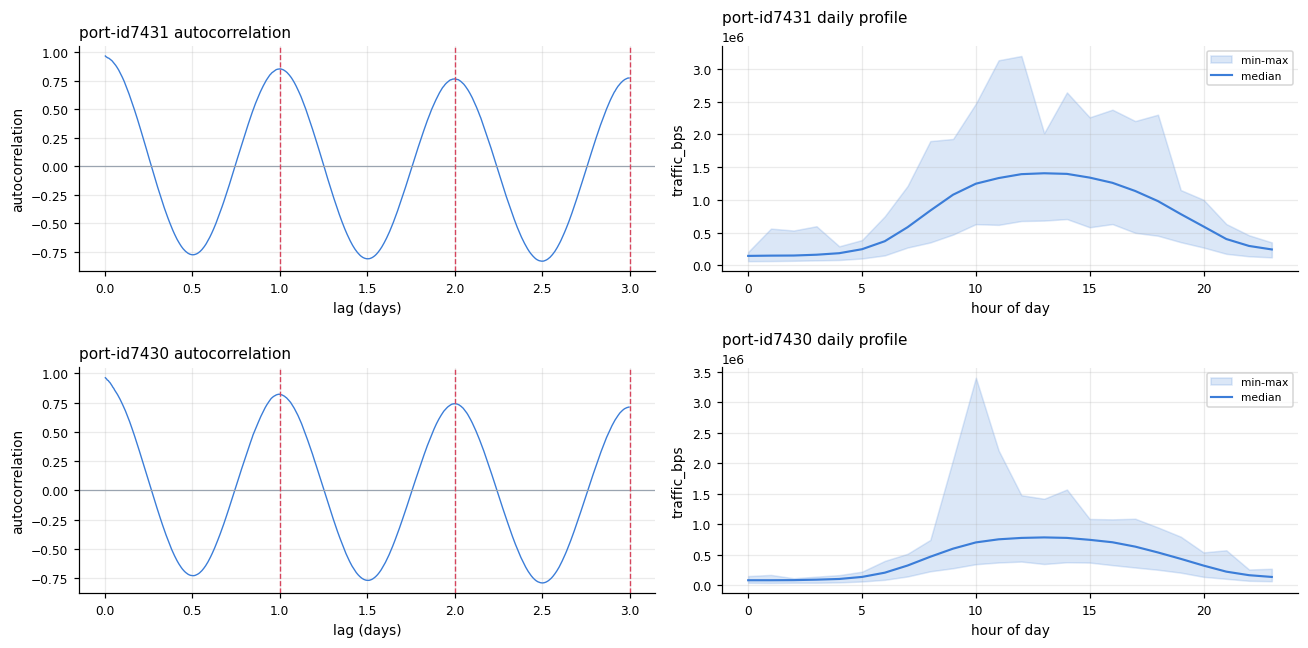

In [5]:
fig, axes = plt.subplots(len(PORTS), 2, figsize=(12, 3.0 * len(PORTS)), squeeze=False)
for row, port in enumerate(PORTS):
    g = series_of(port)
    v = g["value"] - g["value"].mean()
    lags = np.arange(1, 3 * PERIOD)
    acf = np.array([v.autocorr(lag=int(k)) for k in lags])
    axes[row, 0].plot(lags / PERIOD, acf, lw=0.9, color=C["signal"])
    axes[row, 0].axhline(0, color=C["muted"], lw=0.8)
    for d in (1, 2, 3):
        axes[row, 0].axvline(d, color=C["alert"], ls="--", lw=0.9)
    axes[row, 0].set(xlabel="lag (days)", ylabel="autocorrelation",
                     title=f"{port} autocorrelation")

    prof = g.groupby(g["timestamp"].dt.hour)["value"].agg(["median", "min", "max"])
    axes[row, 1].fill_between(prof.index, prof["min"], prof["max"],
                              color=C["signal"], alpha=0.18, label="min-max")
    axes[row, 1].plot(prof.index, prof["median"], lw=1.4, color=C["signal"], label="median")
    axes[row, 1].set(xlabel="hour of day", ylabel=COLUMNS[0], title=f"{port} daily profile")
    axes[row, 1].legend(fontsize=7)
plt.tight_layout()
plt.show()

The autocorrelation peaks sharply at a lag of exactly one day and again at two and three.
The daily profile shows why: a deep night trough and a broad daytime plateau, the same shape
every day.

That has a direct consequence for Lab 01's method. The daytime plateau on `port-id7431` sits
far above the night trough, so any global cutoff is set by the daytime and a night-time
excursion has to clear the *daytime* bar before it is noticed. Keep that in mind at Step 8.

## Step 6 — Split and scale without leaking

The split point is an index, not a random sample. Everything before it trains, everything
after it tests, and the scaler is fitted on the training part alone. Fitting a scaler on the
whole series leaks the test period's mean and spread into training, which flatters every
result that follows.

In [6]:
def split_and_scale(g, train_frac=None):
    """Fit a StandardScaler on the first `train_frac` of the series, transform all of it."""
    train_frac = TRAIN_FRAC if train_frac is None else train_frac
    split = int(train_frac * len(g))
    scaler = StandardScaler().fit(g["value"].to_numpy()[:split].reshape(-1, 1))
    scaled = scaler.transform(g["value"].to_numpy().reshape(-1, 1)).ravel()
    return split, scaled


for port in PORTS:
    g = series_of(port)
    split, scaled = split_and_scale(g)
    print(f"{port}  split at {g['timestamp'][split]}  "
          f"train {split:,} / test {len(g) - split:,}  "
          f"targets in train {int(g['target'][:split].sum())}, "
          f"test {int(g['target'][split:].sum())}")

port-id7431  split at 2026-02-22 00:00:00  train 6,048 / test 2,592  targets in train 36, test 0
port-id7430  split at 2026-02-22 00:00:00  train 6,048 / test 2,592  targets in train 24, test 16


`port-id7431`'s event falls entirely in the training portion and `port-id7430` has 16 of its
40 target samples in the test portion. That asymmetry is normal for a fixed calendar of
events and worth naming rather than engineering away.

These are unsupervised models: no label ever reaches `fit`. Training on a period containing
an event means the model saw a little contamination, which is the realistic case. Scores
below are reported over the whole month, so nothing hides on either side of the split.

## Step 7 — Baseline: the matrix profile

The classical baseline. For every subsequence of length $m$, find the z-normalised Euclidean
distance to its nearest neighbour anywhere else in the series. A subsequence with no close
neighbour is a **discord**: a shape the series never repeats.

The one hyperparameter is $m$. For cyclic data the rule of thumb is one full cycle, so
`SUBSEQ = PERIOD`. Two implementation notes: the distances come from a sliding dot product
computed by FFT, which is what makes this fast enough to write by hand, and a subsequence is
barred from matching its own overlapping neighbours.

In [7]:
def rolling_stats(x, m):
    """Mean and standard deviation of every length-m window, from cumulative sums."""
    c1 = np.concatenate([[0.0], np.cumsum(x)])
    c2 = np.concatenate([[0.0], np.cumsum(x * x)])
    s1, s2 = c1[m:] - c1[:-m], c2[m:] - c2[:-m]
    mu = s1 / m
    return mu, np.sqrt(np.maximum(s2 / m - mu * mu, 1e-12))


def matrix_profile(x, m):
    """Distance from each length-m subsequence to its nearest non-overlapping neighbour.

    Returns one value per subsequence *start*, so the result is len(x) - m + 1 long. A high
    value means that shape happens nowhere else in the series.
    """
    x = np.asarray(x, dtype=float)
    k = len(x) - m + 1
    mu, sig = rolling_stats(x, m)
    n_fft = 1 << int(np.ceil(np.log2(len(x) + m)))
    fx = np.fft.rfft(x, n_fft)
    exclusion = int(np.ceil(m / 4))                 # trivial matches sit next door

    profile = np.empty(k)
    for i in range(k):
        # sliding dot product of subsequence i against the whole series
        qt = np.fft.irfft(fx * np.fft.rfft(x[i:i + m][::-1], n_fft), n_fft)[m - 1:m - 1 + k]
        corr = np.clip((qt - m * mu[i] * mu) / (m * sig[i] * sig), -1, 1)
        d = np.sqrt(np.maximum(2 * m * (1 - corr), 0))
        d[max(0, i - exclusion):min(k, i + exclusion + 1)] = np.inf
        profile[i] = d.min()
    return profile


def discord_rank(profile, target, m=None):
    """Rank of the highest-scoring subsequence whose *span* overlaps a target window.

    A discord at start i covers samples i to i + m, so it hits when any target sample falls
    in that span. Overlap rather than start position, because a discord that begins just
    before an event is describing that event.

    The profile has one value per subsequence start, not per sample, so a per-sample alert
    budget is meaningless on it. Rank is the honest question: how far down the discord list
    do you read before the event appears?
    """
    m = SUBSEQ if m is None else m
    t = np.asarray(target, bool)
    covers = pd.Series(t).rolling(m, min_periods=1).max().to_numpy()[m - 1:].astype(bool)
    for r, i in enumerate(np.argsort(-profile), start=1):
        if covers[i]:
            return r, int(i)
    return None, None


mp_scores = {}
for port in PORTS:
    g = series_of(port)
    prof = matrix_profile(g["value"].to_numpy(), SUBSEQ)
    mp_scores[port] = np.concatenate([prof, np.full(SUBSEQ - 1, np.nan)])
    top = int(np.argmax(prof))
    rank, at = discord_rank(prof, g["target"])
    print(f"{port}  top discord starts {g['timestamp'][top]}  distance {prof[top]:.2f}  "
          f"labels in its span: {set(g['event_label'][top:top + SUBSEQ]) - {'normal'} or 'none'}")
    print(f"{'':13}first discord whose span covers a target: rank {rank} of {len(prof):,}, "
          f"starting {g['timestamp'][at]}")

port-id7431  top discord starts 2026-02-08 00:35:00  distance 8.56  labels in its span: {'large_file_backup'}
             first discord whose span covers a target: rank 1 of 8,353, starting 2026-02-08 00:35:00


port-id7430  top discord starts 2026-02-24 11:50:00  distance 8.11  labels in its span: {'abnormal_device_sender'}
             first discord whose span covers a target: rank 1 of 8,353, starting 2026-02-24 11:50:00


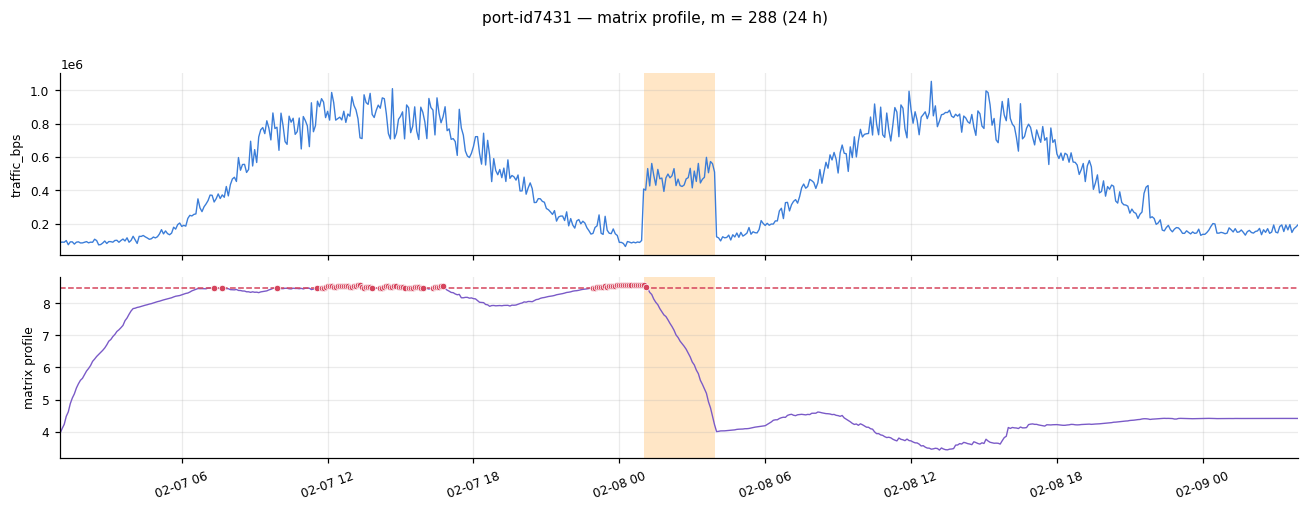

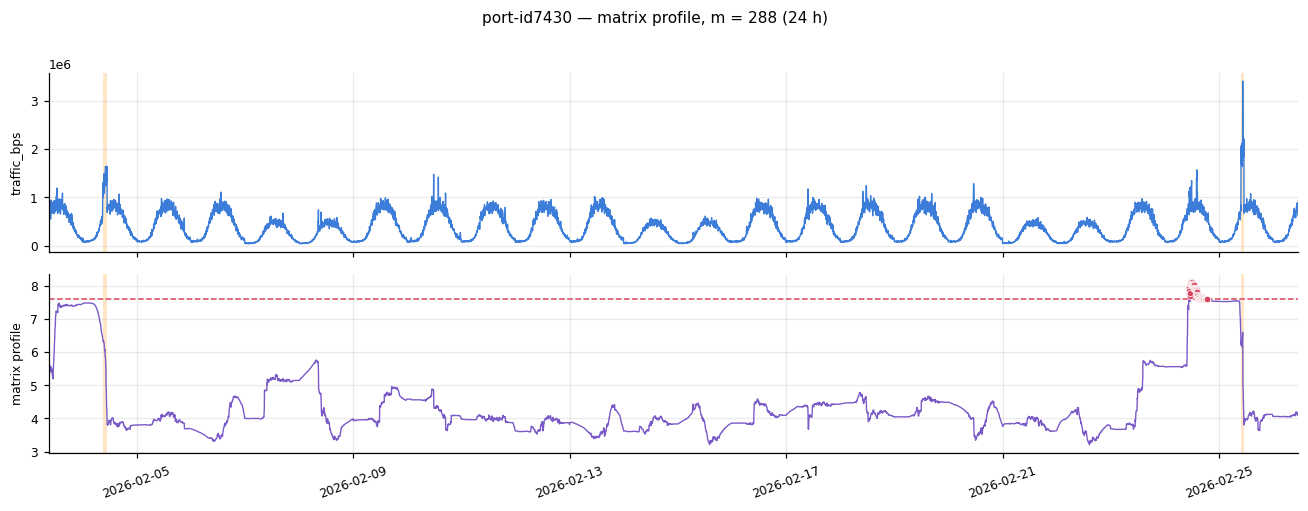

In [8]:
for port in PORTS:
    g = series_of(port)
    plot_series(g, {"matrix profile": mp_scores[port]},
                title=f"{port} — matrix profile, m = {SUBSEQ} ({SUBSEQ * CADENCE / 3600:.0f} h)")

On both ports the largest discord of the month, out of more than eight thousand candidate
subsequences, spans a labelled window. Rank 1 on each. Note that neither one *starts* inside
the event: a discord beginning shortly before an anomaly is the normal case, because the
unrepeated shape is the approach and the excursion together. The matrix profile never saw a
label and has no notion of night or day; it only knows that this stretch of shape is unlike
every other stretch, and that is what makes it a fair baseline.

One value per subsequence *start*, so a discord beginning at 00:35 describes the day that
follows it. That is why the tables from Step 8 onward leave the matrix profile out: those
score one sample at a time and cut at a shared per-sample budget, which this profile has no
sensible way to answer.

## Step 8 — Off-the-shelf models on raw values

Now the standard scikit-learn outlier detectors, fitted on the scaled training values, one
feature per sample. This is what "just throw an anomaly detector at it" looks like.

In [9]:
def fit_models(train, full, seed=0):
    """Fit the three detectors on `train` and score `full`. Higher score = more anomalous.

    Each library method returns higher-is-more-normal, so every score is negated.
    OneClassSVM is fitted on every tenth training row, which keeps a quadratic-time solver
    inside a teaching notebook's patience.
    """
    return {
        "IsolationForest": -IsolationForest(random_state=seed).fit(train).score_samples(full),
        "OneClassSVM": -OneClassSVM(nu=0.01, gamma="scale").fit(train[::10]).score_samples(full),
        "LOF": -LocalOutlierFactor(novelty=True).fit(train).score_samples(full),
    }


rows, raw_scores = [], {}
for port in PORTS:
    g = series_of(port)
    split, scaled = split_and_scale(g)
    X = scaled.reshape(-1, 1)
    raw_scores[port] = fit_models(X[:split], X)
    for name, s in raw_scores[port].items():
        rows.append(evaluate(f"raw {name}", port, s, g["target"]))

pd.DataFrame(rows)

,port,method,alerts,caught,of,precision
0,7431,raw IsolationForest,86,0,36,0.000
1,7431,raw OneClassSVM,87,0,36,0.000
2,7431,raw LOF,87,0,36,0.000
3,7430,raw IsolationForest,86,39,40,0.453
4,7430,raw OneClassSVM,87,36,40,0.414
5,7430,raw LOF,87,21,40,0.241


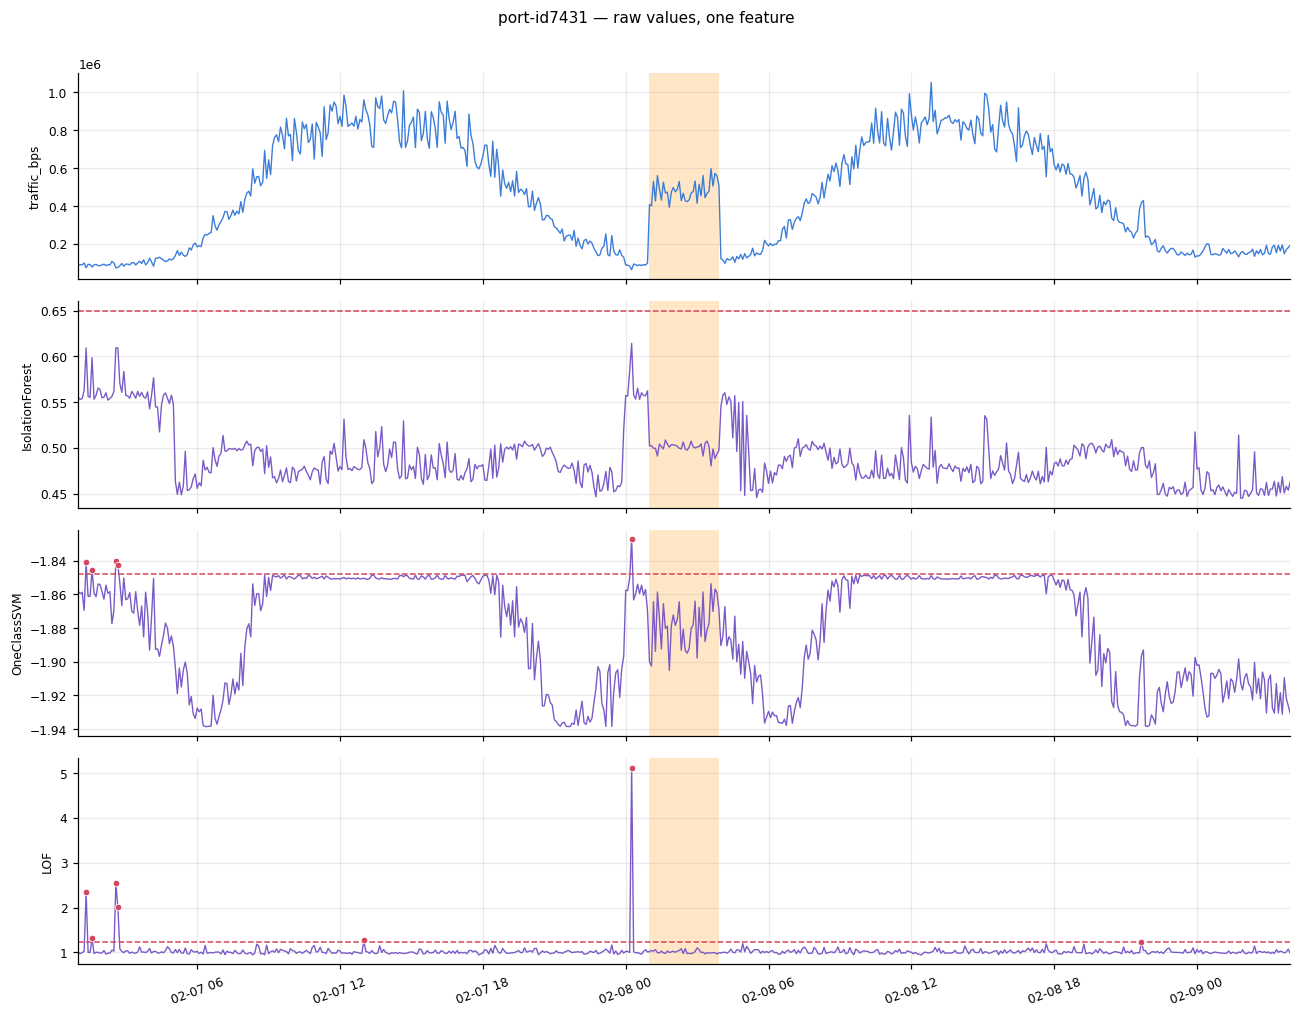

In [10]:
port = PORTS[0]
plot_series(series_of(port), raw_scores[port], title=f"{port} — raw values, one feature")

On `port-id7430` the three models do fine: its events are a daytime surge, extreme in
absolute terms, and a global model sees them.

On `port-id7431` all three catch **zero**. Look at the top panel and the reason is plain.
The bulk transfer runs at roughly the level of an ordinary weekday afternoon. It happens at
one in the morning, when the port is normally near idle, and that is the entire anomaly. A
model given one number per sample and no clock cannot express "high for 1 a.m." — it only
knows "high", and this is not high.

The rest of the lab is two ways of giving the model the clock.

## Step 9 — Remove the seasonality

Decompose the series additively into trend, season and residual:

$$x_t = \mathrm{trend}_t + \mathrm{season}_t + \mathrm{resid}_t$$

The trend is a centred rolling mean over one full cycle, which averages the cycle away. The
season is the typical shape of a day, taken as the median of the detrended values at each
position in the cycle; a median rather than a mean so one anomalous day does not redraw the
profile. What is left is the residual, and *that* is what gets scored.

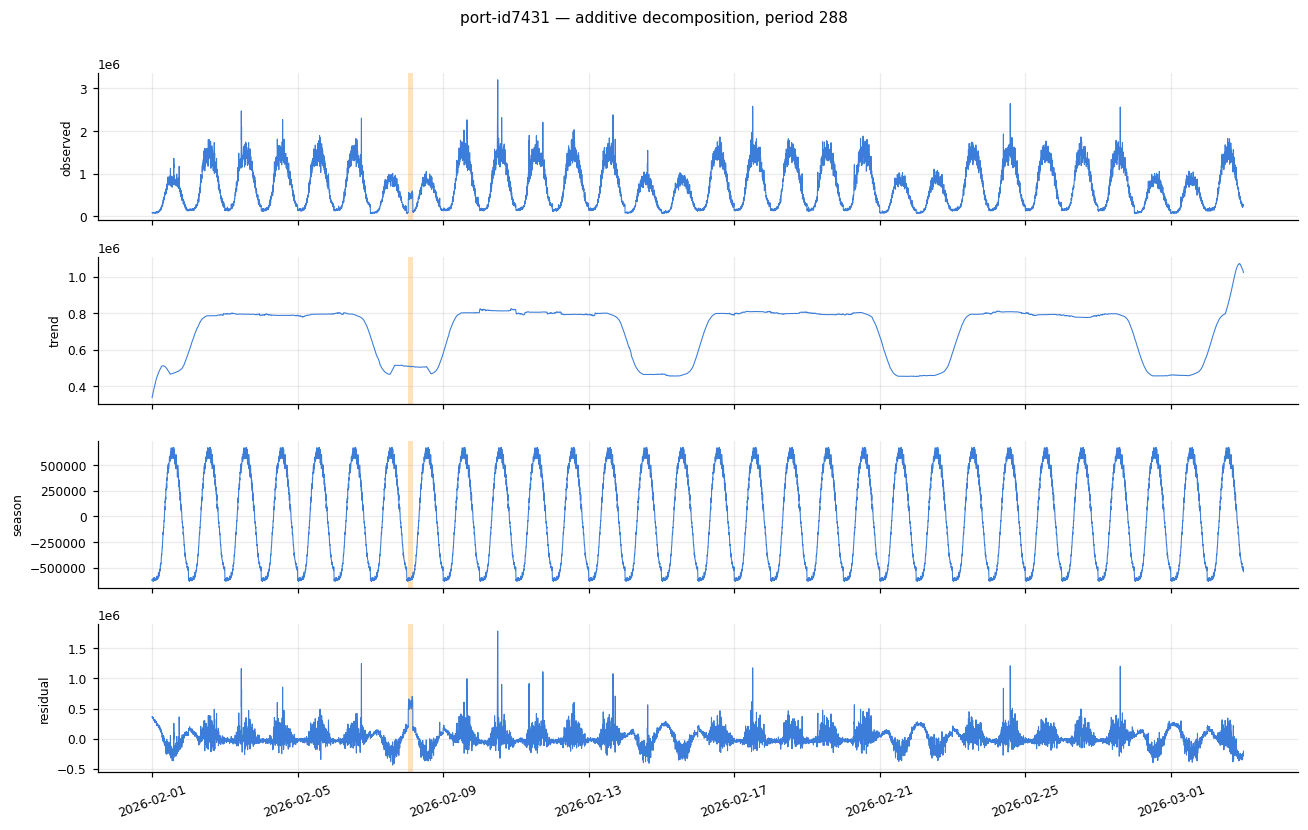

In [11]:
def decompose(x, period=None):
    """Additive trend / season / residual. A median seasonal profile resists contamination."""
    period = PERIOD if period is None else period
    s = pd.Series(np.asarray(x, dtype=float))
    trend = s.rolling(period, center=True, min_periods=period // 2).mean()
    detrended = s - trend
    season = detrended.groupby(np.arange(len(s)) % period).transform("median")
    return trend.to_numpy(), season.to_numpy(), (s - trend - season).to_numpy()


port = PORTS[0]
g = series_of(port)
trend, season, resid = decompose(g["value"])

fig, axes = plt.subplots(4, 1, figsize=(12, 7.5), sharex=True)
for ax, (name, v) in zip(axes, [("observed", g["value"].to_numpy()), ("trend", trend),
                                ("season", season), ("residual", resid)]):
    ax.plot(g["timestamp"], v, lw=0.7, color=C["signal"])
    ax.set_ylabel(name, fontsize=8)
for ax in axes:
    for a, b in target_runs(g):
        ax.axvspan(a, b, color=C["truth"], alpha=0.3, lw=0)
axes[-1].tick_params(axis="x", labelrotation=20)
fig.suptitle(f"{port} — additive decomposition, period {PERIOD}", y=1.0, fontsize=10)
fig.tight_layout()
plt.show()

The residual panel is the point, but at full-month scale the shaded sliver is too narrow to
read. Zoom in, and put a number on what the decomposition did.

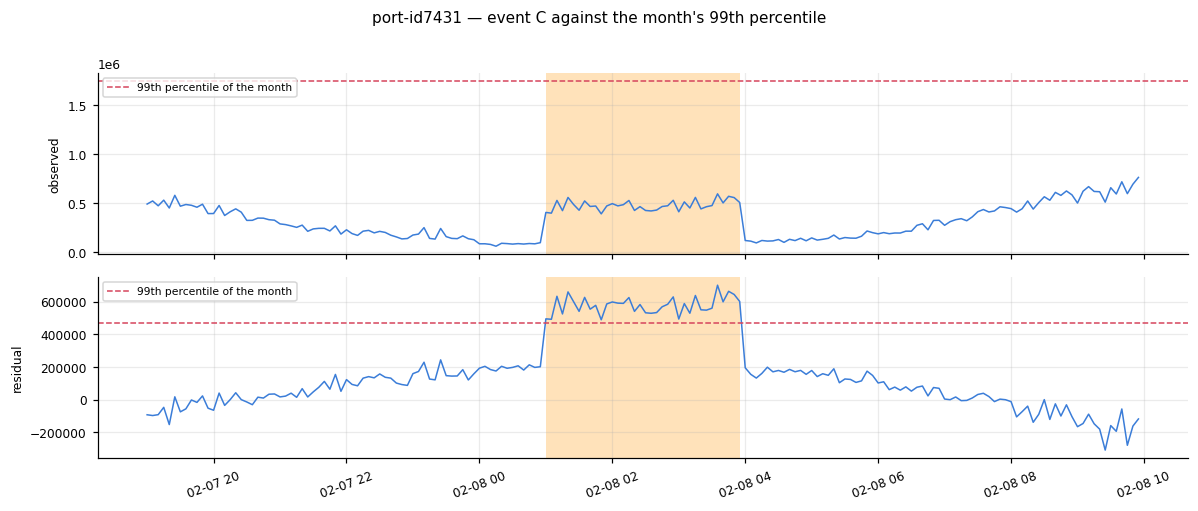

observed  event peak sits at the 49.3% percentile of the month, 4,377 samples are higher, 0/36 above the 99th
residual  event peak sits at the 99.7% percentile of the month, 29 samples are higher, 36/36 above the 99th


In [12]:
mask = g["target"].to_numpy()
zoom = (g.loc[mask, "timestamp"].min() - pd.Timedelta(hours=6),
        g.loc[mask, "timestamp"].max() + pd.Timedelta(hours=6))
view = g["timestamp"].between(*zoom).to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)
for ax, (name, v) in zip(axes, [("observed", g["value"].to_numpy()), ("residual", resid)]):
    ax.plot(g.loc[view, "timestamp"], pd.Series(v)[view], lw=1.0, color=C["signal"])
    ax.axhline(np.nanquantile(v, 0.99), color=C["alert"], ls="--", lw=1.0,
               label="99th percentile of the month")
    for a, b in target_runs(g):
        ax.axvspan(a, b, color=C["truth"], alpha=0.3, lw=0)
    ax.set_ylabel(name, fontsize=8)
    ax.legend(fontsize=7, loc="upper left")
axes[-1].tick_params(axis="x", labelrotation=20)
fig.suptitle(f"{port} — event C against the month's 99th percentile", y=1.0, fontsize=10)
fig.tight_layout()
plt.show()

for name, v in [("observed", g["value"].to_numpy()), ("residual", resid)]:
    v = pd.Series(v)
    pct = v.rank(pct=True)[mask]
    print(f"{name:9} event peak sits at the {pct.max():.1%} percentile of the month, "
          f"{int((v > v[mask].max()).sum()):,} samples are higher, "
          f"{int((v[mask] > v.quantile(0.99)).sum())}/{int(mask.sum())} above the 99th")

The two lines say it exactly. In the observed series the event's *peak* sits at the 49th
percentile of the month, with 4,377 ordinary samples above it, and not one of its 36 samples
clears the 99th percentile. In the residual all 36 clear it, and its peak moves from the 49th
percentile to the 99.7th.

The data did not change. Subtracting the expected shape of a day converted a contextual
anomaly into an absolute one.

Refit the same three models on the residual, changing nothing else.

In [13]:
resid_scores = {}
for port in PORTS:
    g = series_of(port)
    _, _, r = decompose(g["value"])
    r = np.nan_to_num(r, nan=0.0)
    split = int(TRAIN_FRAC * len(g))
    X = StandardScaler().fit(r[:split].reshape(-1, 1)).transform(r.reshape(-1, 1))
    resid_scores[port] = fit_models(X[:split], X)
    for name, s in resid_scores[port].items():
        rows.append(evaluate(f"deseasonalised {name}", port, s, g["target"]))

pd.DataFrame(rows).query("method.str.contains('raw|deseasonalised')")

,port,method,alerts,caught,of,precision
0,7431,raw IsolationForest,86,0,36,0.000
1,7431,raw OneClassSVM,87,0,36,0.000
2,7431,raw LOF,87,0,36,0.000
3,7430,raw IsolationForest,86,39,40,0.453
4,7430,raw OneClassSVM,87,36,40,0.414
5,7430,raw LOF,87,21,40,0.241
6,7431,deseasonalised IsolationForest,87,23,36,0.264
7,7431,deseasonalised OneClassSVM,87,4,36,0.046
8,7431,deseasonalised LOF,87,5,36,0.057
9,7430,deseasonalised IsolationForest,85,40,40,0.471


On `port-id7431`, `IsolationForest` goes from 0 of 36 to 23. The other two move from 0 to 4
and 5, which is a detection rather than a fix: a single global cut on the residual still
struggles when the residual's own spread is dominated by daytime noise.

On `port-id7430` nothing much changes, because its events were already absolute. That is the
expected result and it is worth seeing. Deseasonalising is not a general improvement, it is a
targeted one, and it costs a parameter you now have to keep correct.

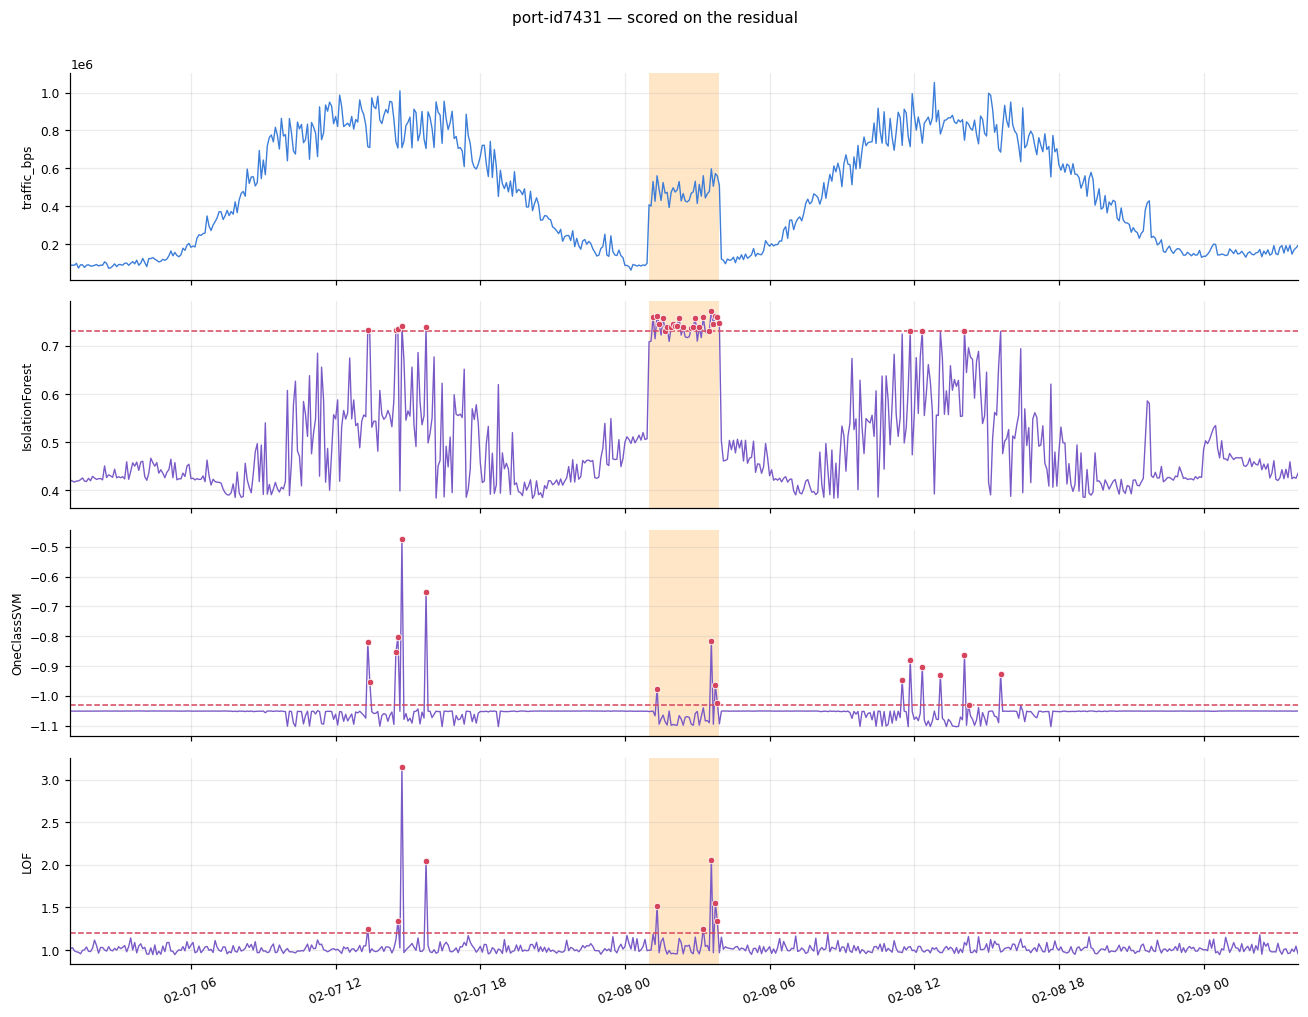

In [14]:
port = PORTS[0]
plot_series(series_of(port), resid_scores[port], title=f"{port} — scored on the residual")

## Step 10 — Sliding windows

The other way to give a model context: stop feeding it one number and feed it the last
`N_INPUT` numbers as a vector. A sample is then judged by the *shape* it sits in rather than
by its own height.

```
value:  [10, 20, 30, 40, 50, 60, ...]
rows:   [10, 20, 30]
            [20, 30, 40]
                [30, 40, 50]
```

`N_INPUT` is a real choice. Too short and a window carries no context; as it approaches
`PERIOD` every window becomes a whole day and they all look alike again. The default here is
36 samples, three hours.

In [15]:
def sliding_windows(x, n_input=None):
    """Rows of `n_input` consecutive values. Row i ends at sample i + n_input - 1."""
    n_input = N_INPUT if n_input is None else n_input
    return np.lib.stride_tricks.sliding_window_view(np.asarray(x, dtype=float), n_input)


window_scores = {}
for port in PORTS:
    g = series_of(port)
    W = sliding_windows(g["value"])
    split = int(TRAIN_FRAC * len(W))
    Xw = StandardScaler().fit(W[:split]).transform(W)
    scored = fit_models(Xw[:split], Xw)
    # a window's score belongs to the sample it ends on, so pad the leading samples
    window_scores[port] = {k: np.concatenate([np.full(N_INPUT - 1, np.nan), v])
                           for k, v in scored.items()}
    for name, s in window_scores[port].items():
        rows.append(evaluate(f"window{N_INPUT} {name}", port, s, g["target"]))

pd.DataFrame(rows).query("method.str.contains('window')")

,port,method,alerts,caught,of,precision
12,7431,window36 IsolationForest,87,15,36,0.172
13,7431,window36 OneClassSVM,87,0,36,0.000
14,7431,window36 LOF,87,31,36,0.356
15,7430,window36 IsolationForest,87,28,40,0.322
16,7430,window36 OneClassSVM,87,21,40,0.241
17,7430,window36 LOF,87,10,40,0.115


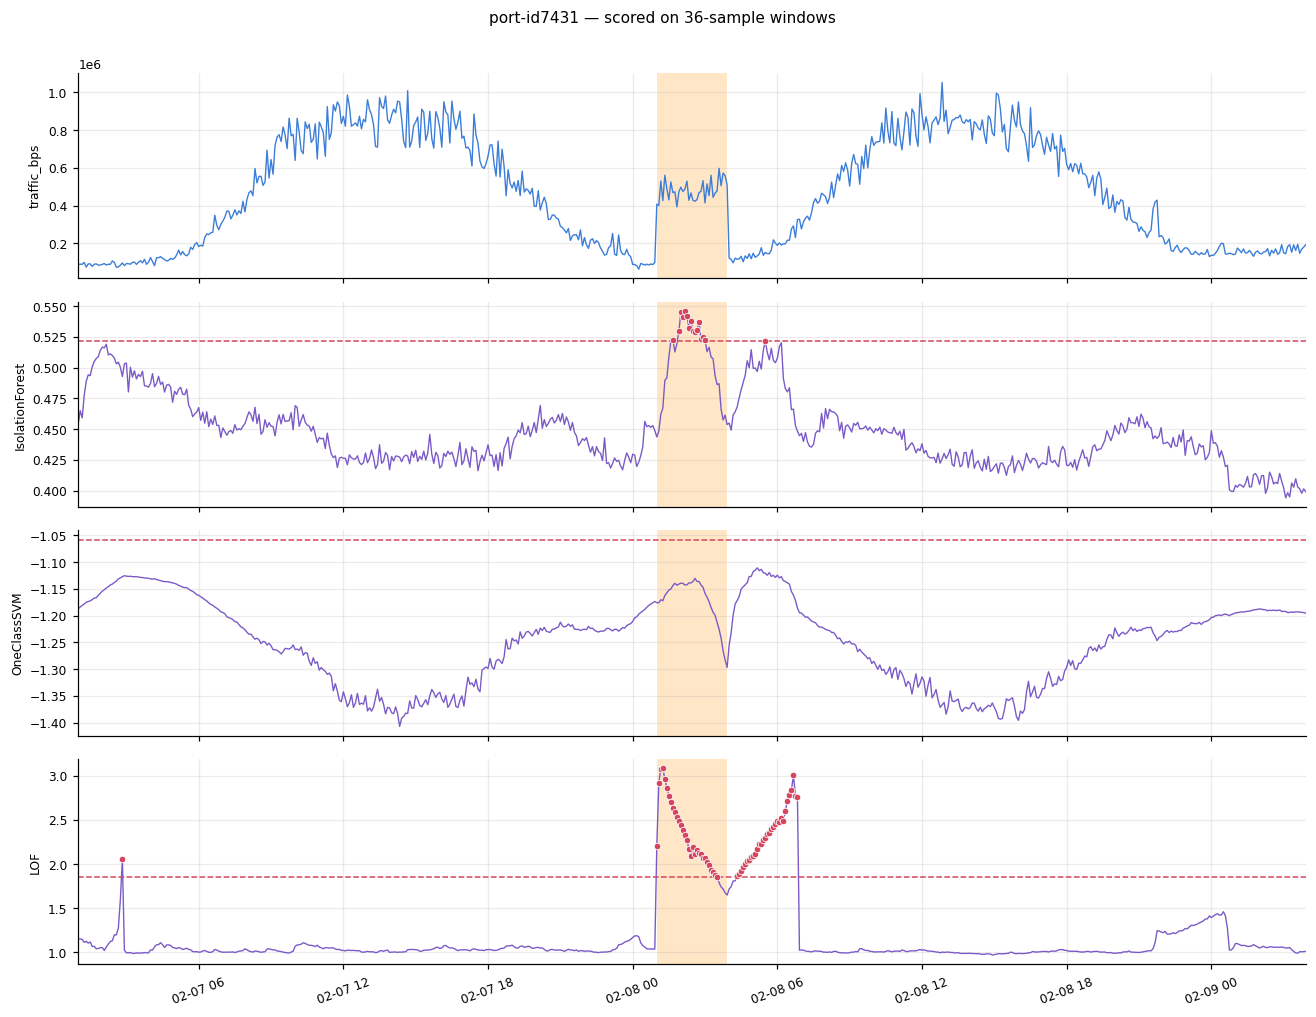

In [16]:
port = PORTS[0]
plot_series(series_of(port), window_scores[port],
            title=f"{port} — scored on {N_INPUT}-sample windows")

On `port-id7431`, `LocalOutlierFactor` goes from 0 of 36 to 31, the best result any method
reaches on that event, and it got there without computing a seasonal profile at all. That
follows from what LOF measures. It scores a point by the density of its neighbours, and in 36
dimensions a 3 a.m. ramp has no neighbours; in one dimension it sat in the middle of a
crowded axis.

The same change makes things worse on `port-id7430`, where LOF drops from 21 to 10 and
`IsolationForest` from 39 to 28. Windowing spends its sensitivity on shape, and an event that
was already obvious by height gets diluted across 36 dimensions.

So the two remedies are not interchangeable. The decomposition subtracts the expected shape;
the window lets the model compare shapes. Which one wins depends on the anomaly, and no
single row of the table is best on both ports.

## Step 11 — Everything side by side

Every method above at the same alert budget, so the comparison is about the method rather
than about how loudly it was tuned.

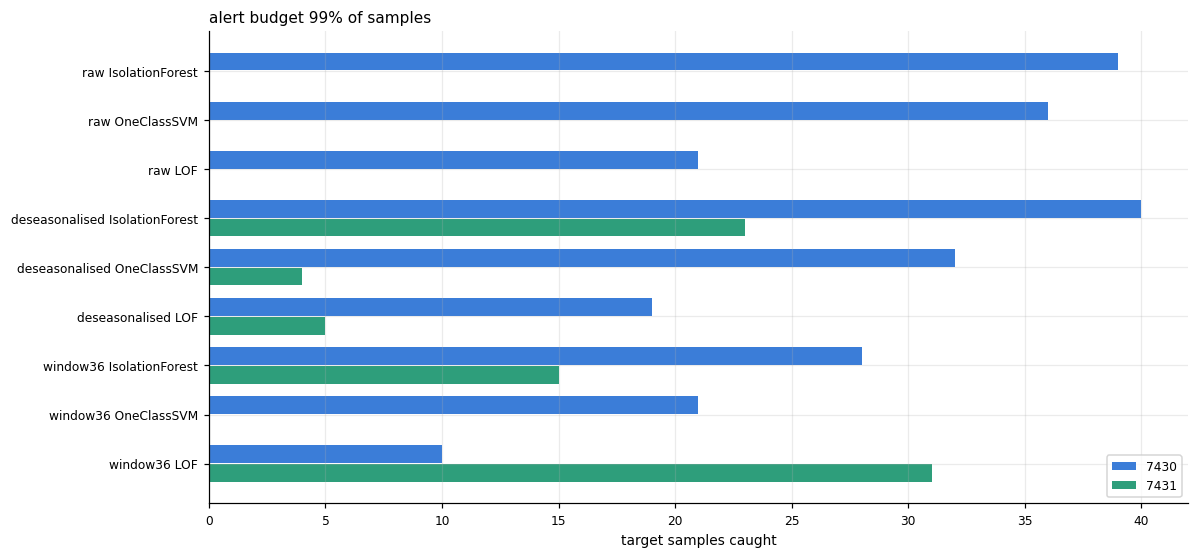

,port,method,alerts,caught,of,precision
0,7431,raw IsolationForest,86,0,36,0.000
1,7431,raw OneClassSVM,87,0,36,0.000
2,7431,raw LOF,87,0,36,0.000
3,7430,raw IsolationForest,86,39,40,0.453
4,7430,raw OneClassSVM,87,36,40,0.414
5,7430,raw LOF,87,21,40,0.241
6,7431,deseasonalised IsolationForest,87,23,36,0.264
7,7431,deseasonalised OneClassSVM,87,4,36,0.046
8,7431,deseasonalised LOF,87,5,36,0.057
9,7430,deseasonalised IsolationForest,85,40,40,0.471


In [17]:
summary = (pd.DataFrame(rows)
           .drop_duplicates(subset=["port", "method"])
           .pivot(index="method", columns="port", values="caught")
           .fillna(0).astype(int))
order = [f"{p} {m}" for p in ("raw", "deseasonalised", f"window{N_INPUT}")
         for m in ("IsolationForest", "OneClassSVM", "LOF")]
summary = summary.reindex([m for m in order if m in summary.index])

fig, ax = plt.subplots(figsize=(11, 0.42 * len(summary) + 1.4))
y = np.arange(len(summary))
for k, port in enumerate(summary.columns):
    ax.barh(y + (k - 0.5) * 0.38, summary[port], height=0.36,
            color=[C["signal"], C["peer"]][k % 2], label=port)
ax.set_yticks(y, summary.index, fontsize=8)
ax.invert_yaxis()
ax.set(xlabel="target samples caught", title=f"alert budget {BUDGET:.0%} of samples")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(rows).drop_duplicates(subset=["port", "method"])

Read the two ports as two different problems. `port-id7430`'s events are absolute: raw
scoring already works, and every later step costs it accuracy. `port-id7431`'s event is
contextual: raw scoring finds nothing at all, and the remedies recover between 4 and 31 of
its 36 samples depending on which pairing you pick.

No row wins both columns. That is the lab's actual result, and it is more useful than a
ranking would have been. Feature engineering that encodes time matters more here than the
choice of model, and picking it wrong costs you on the anomalies that did not need it.

The matrix profile is not in this chart, for the reason given at Step 7. Judged on its own
terms it was the strongest single result in the notebook: rank-1 discord on both ports, one
parameter, no training, no scaler, no split.

One caveat worth carrying forward. Event C is a nightly bulk transfer, and this course's
change calendar declares it a *planned* backup. Detecting it proves the method works; whether
it should page anyone is a separate question, answered by the calendar rather than by the
detector.

## Exercises

1. **Window length.** Set `N_INPUT` to `12`, then `288`, and re-run Step 10. At `288` the
   detection collapses. Explain it from the definition of the window.
2. **Subsequence length.** Set `SUBSEQ` to `PERIOD // 4`, then `PERIOD * 2`, and re-run
   Step 7. Does the top discord stay on the event?
3. **Additive or multiplicative?** `decompose` assumes the seasonal amplitude is independent
   of the level. Plot `value / trend` instead of `value - trend` and decide which this data
   is.
4. **A different port.** Set `PORTS = ["port-id7427"]` and `EVENT_TYPES =
   ["queue_congestion", "load_sensitive_link_issue"]`. Those events are short. Which of the
   four approaches survives an event lasting under an hour?
5. **The contaminated profile.** `decompose` takes a median across days. Change it to a mean
   and re-run Step 9. How much does one anomalous day move the seasonal profile, and how much
   of the residual does it eat?

In [18]:
# YOUR CODE HERE

## Summary

**Seasonality is a property of the data, not a nuisance.** The autocorrelation and the daily
profile identify it in two plots, and everything downstream depends on the period they give.

**Split by index and fit the scaler on the training part.** A random split or a globally
fitted scaler leaks the future backwards, and the result is a number that will not survive
production.

**The matrix profile is a strong baseline for one parameter.** No training, no labels, one
subsequence length, and its rank-1 discord landed inside a labelled window on both ports.

**A contextual anomaly is invisible to a model with no clock.** Three standard detectors on
raw values caught nothing on `port-id7431`. Deseasonalising recovered 23 of 36 samples with
`IsolationForest`; sliding windows recovered 31 with `LocalOutlierFactor`. Neither changed
the model, and each cost accuracy on the port whose events were already absolute.

Both labs have scored one signal at a time. The events that stayed invisible here, the
broadcast storm and the multicast flooding, are visible in a *ratio* between two counters,
which is where multivariate detection starts.